# Forecasting Hourly Energy Demand: SARIMA vs. Prophet vs. Gradient Boosting

**Goal:** Forecast electricity demand for the PJM East region (US) and compare three different approaches:

1. A classical statistical model (SARIMA)
2. A decomposition-based model (Prophet)
3. A machine-learning model with engineered lag features (LightGBM). 


**Pipeline overview:**
1. Data loading & quality checks
2. Exploratory analysis for seasonality
3. Time-series cross-validation setup
4. Model 1 — SARIMA on daily aggregates
5. Model 2 — Prophet
6. Model 3 — LightGBM with lag & calendar features (+ quantile intervals)
7. Backtest comparison & conclusions

## Data
`PJME_hourly.csv` from the Kaggle dataset ["Hourly Energy Consumption"](https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption). Contains ~145k hourly observations of PJM East demand in megawatts, 2002–2018.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random



df = pd.read_csv("PJME_hourly.csv", parse_dates=["Datetime"])
df.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [2]:
df = df.rename(columns={"Datetime": "ds", "PJME_MW": "y"}).sort_values("ds").reset_index(drop=True)
print(df.shape)
df.head()

(145366, 2)


,ds,y
0,2002-01-01 01:00:00,30393.0
1,2002-01-01 02:00:00,29265.0
2,2002-01-01 03:00:00,28357.0
3,2002-01-01 04:00:00,27899.0
4,2002-01-01 05:00:00,28057.0


## 1. Data quality checks

Issues of duplicate timestamps (daylight-saving fall-back) and missing hours (spring-forward, outages). We resolve duplicates by averaging and reindex to a complete hourly grid, interpolating the small gaps. Important to have no gaps in the data for the sake of the lags in future models. Not many instances but need repairing regardless.

In [3]:
dupes = df["ds"].duplicated().sum()
df = df.groupby("ds", as_index=False)["y"].mean()

full_idx = pd.date_range(df["ds"].min(), df["ds"].max(), freq="h")
df = df.set_index("ds").reindex(full_idx)
n_missing = df["y"].isna().sum()
df["y"] = df["y"].interpolate(method="time")
df.index.name = "ds"

print(f"Duplicate timestamps resolved: {dupes}")
print(f"Missing hours filled: {n_missing}")
print(f"Continuous range: {df.index.min()} → {df.index.max()}  ({len(df):,} hours)")

Duplicate timestamps resolved: 4
Missing hours filled: 30
Continuous range: 2002-01-01 01:00:00 → 2018-08-03 00:00:00  (145,392 hours)


## 2. Exploratory analysis: three nested seasonalities

Energy demand has structure at three separate time scales. Daily (different energy consumption during waking hours), weekly (weekends differ from weekdays), and yearly (weather and seasons).

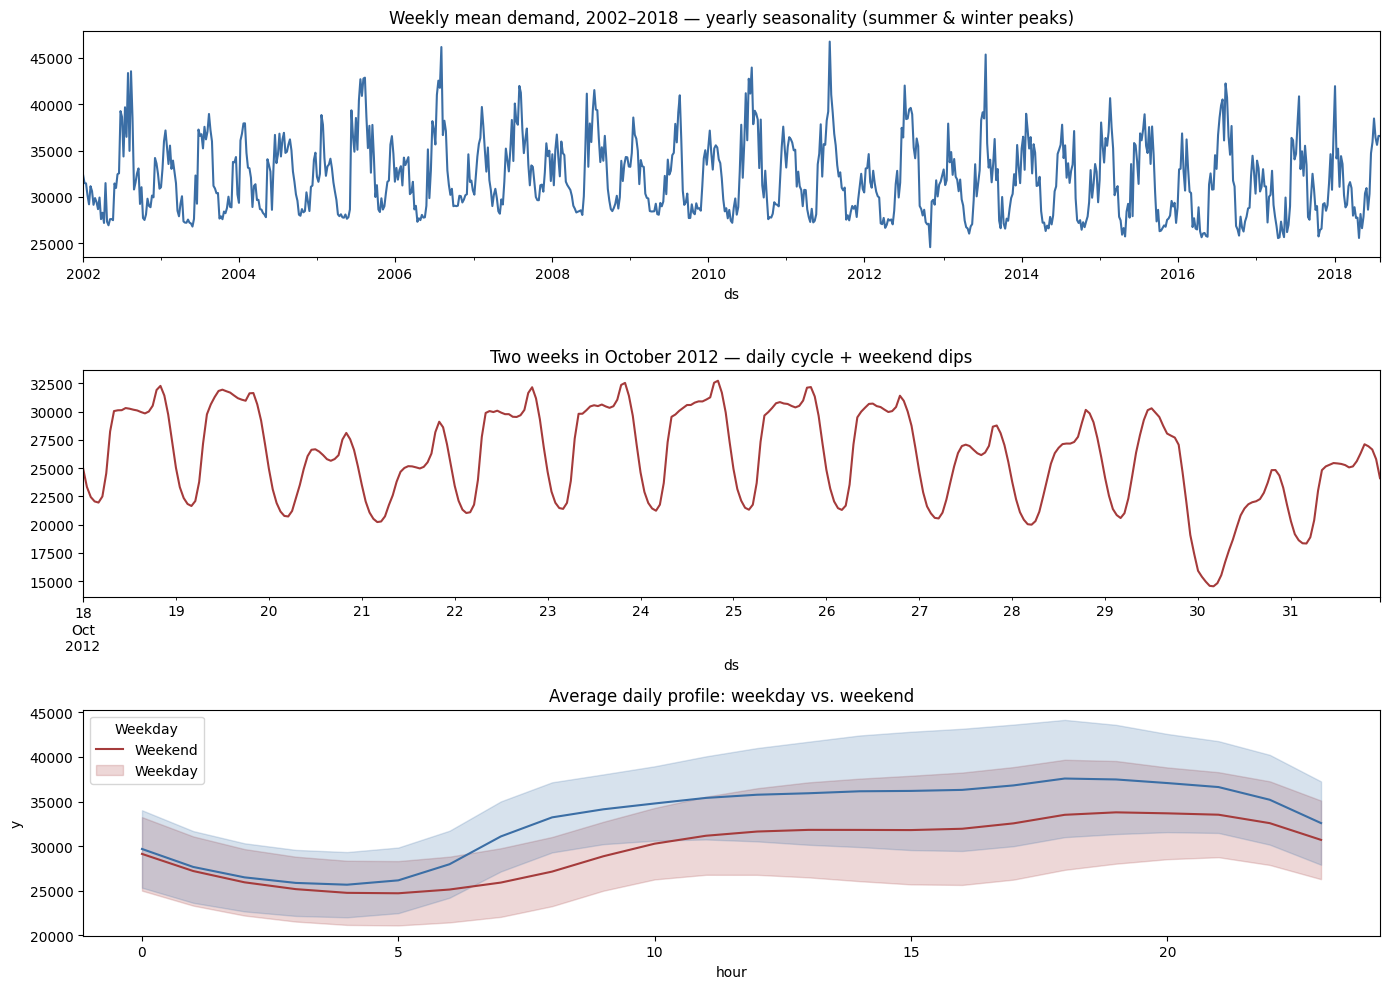

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

df["y"].resample("W").mean().plot(ax=axes[0], color="#3b6ea5")
axes[0].set_title("Weekly mean demand, 2002–2018 — yearly seasonality (summer & winter peaks)")

# Pick a random 14-day window that lies fully within the dataset
window_days = 14
max_start = (df.index.max() - df.index.min()).days - window_days
random_offset = random.randint(0, max_start)
start = (df.index.min() + pd.Timedelta(days=random_offset)).normalize()
end = start + pd.Timedelta(days=window_days) - pd.Timedelta(hours=1)

df.loc[start:end, "y"].plot(ax=axes[1], color="#a53b3b")
axes[1].set_title(f"Two weeks in {start.strftime('%B %Y')} — daily cycle + weekend dips")

hourly_profile = df.assign(hour=df.index.hour, weekday=df.index.dayofweek < 5)
sns.lineplot(data=hourly_profile, x="hour", y="y", hue="weekday",
             estimator="mean", errorbar="sd", ax=axes[2], palette=["#a53b3b", "#3b6ea5"])
axes[2].set_title("Average daily profile: weekday vs. weekend")
axes[2].legend(title="Weekday", labels=["Weekend", "Weekday"])

plt.tight_layout(); plt.show()

**Observations:**

- **Yearly seasonality (top):** Weekly mean demand oscillates between roughly 25,000–30,000 MW in the shoulder seasons and spikes above 40,000 MW during summer peaks, with the sharpest outliers appearing in hot years like 2006, 2011, and 2013. The pattern is remarkably stable across the full 2002–2018 span, though peak intensity varies year to year, suggesting weather is also an important factor (not a groundbreaking observation by any means).

- **Daily cycle (middle, random two-week window — October 2010):** Daily rhythm is clear, low demand troughs in the early morning and grows to a midday/evening plateau. The dips are sharper and deeper on some days than others (weekends), which the bottom panel confirms directly.

- **Weekday vs. weekend profile (bottom):** Weekdays (blue) run consistently 3,000–5,000 MW above weekends (red) from mid-morning through evening, with the gap widening most around hour 10–20 — the working day. Both curves share the same basic shape, so the weekday/weekend effect is more of a level shift as opposed to a change in shape.


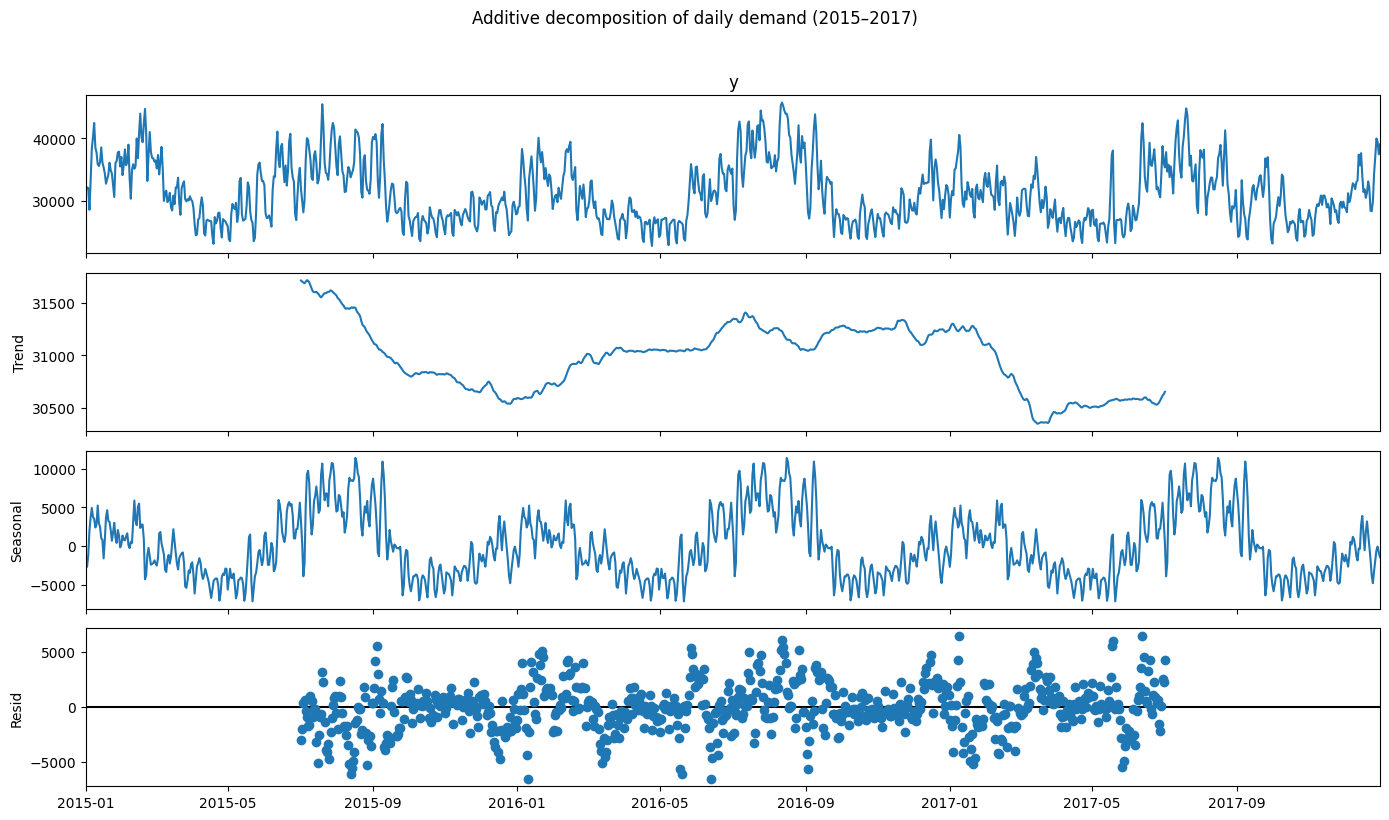

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose

daily = df["y"].resample("D").mean()
decomp = seasonal_decompose(daily.loc["2015":"2017"], period=365, model="additive")
fig = decomp.plot()
fig.set_size_inches(14, 8)
fig.suptitle("Additive decomposition of daily demand (2015–2017)", y=1.02)
plt.tight_layout(); plt.show()

## 3. Evaluation protocol: rolling-origin backtesting

For this analysis we'll use rolling-origin evaluation, which trains on everything up to a cutoff, forecasts a fixed horizon, slides the cutoff forward, and repeats. We will use a one week horizon (7 days, 168 hours), 6 cutoffs spaced 60 days apart across 2017-2018 (the end of the data), and we will use mean average error and meane average percentage error for point accuracy. Also empirical coverage of the 90% prediction interval for uncertainty quality.

In [6]:
HORIZON_H = 168  # 7 days, hourly

cutoffs = pd.date_range("2017-06-01", "2018-04-01", periods=6).normalize()

def backtest_frames(cutoff):
    train = df.loc[:cutoff - pd.Timedelta(hours=1)]
    test  = df.loc[cutoff : cutoff + pd.Timedelta(hours=HORIZON_H - 1)]
    return train, test

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def coverage(y_true, lo, hi):
    return np.mean((y_true >= lo) & (y_true <= hi)) * 100

results = []   # collected across all models
print("Backtest cutoffs:", [c.date().isoformat() for c in cutoffs])

Backtest cutoffs: ['2017-06-01', '2017-07-31', '2017-09-30', '2017-11-30', '2018-01-30', '2018-04-01']


## 4. Model 1 — SARIMA (on daily aggregates)

SARIMA is the classical benchmark, but it quickly becomes constrained with larger seasonal periods. Also, hourly data has nested seasonalities (24 and 168) that can't be represented simultaneously. Because of this we will model daily totals with weekly seasonality `(s=7)`, then disaggregate to hours using the average intraday profile from training data. 

Order selection: we difference once seasonally, and pick a small `(p,d,q)(P,D,Q)` configuration guided by AIC.

In [7]:
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
warnings.filterwarnings("ignore")

def intraday_profile(train):
    """Mean share of daily demand per (dayofweek, hour) from training data."""
    t = train.copy()
    t["share"] = t["y"] / t["y"].resample("D").transform("sum")
    return t.groupby([t.index.dayofweek, t.index.hour])["share"].mean()

for cutoff in cutoffs:
    train, test = backtest_frames(cutoff)
    daily_train = train["y"].resample("D").sum().iloc[-3*365:]   # last 3y is enough

    model = SARIMAX(daily_train, order=(1, 0, 1), seasonal_order=(1, 1, 1, 7),
                    trend="c", enforce_stationarity=False).fit(disp=False)
    fc = model.get_forecast(steps=7)
    daily_mean = fc.predicted_mean
    daily_ci   = fc.conf_int(alpha=0.10)  # 90% interval

    profile = intraday_profile(train)
    idx = test.index
    shares = pd.Series([profile.loc[(ts.dayofweek, ts.hour)] for ts in idx], index=idx)
    day_key = idx.normalize()
    pred = shares.values * daily_mean.reindex(day_key).values
    lo   = shares.values * daily_ci.iloc[:, 0].reindex(day_key).values
    hi   = shares.values * daily_ci.iloc[:, 1].reindex(day_key).values

    results.append({"model": "SARIMA (daily→hourly)", "cutoff": cutoff,
                    "MAE": np.mean(np.abs(test['y'].values - pred)),
                    "MAPE": mape(test["y"].values, pred),
                    "coverage90": coverage(test["y"].values, lo, hi)})

pd.DataFrame([r for r in results if r["model"].startswith("SARIMA")]).round(2)

,model,cutoff,MAE,MAPE,coverage90
0,SARIMA (daily→hourly),2017-06-01,1696.38,6.09,100.00
1,SARIMA (daily→hourly),2017-07-31,3370.64,9.66,89.29
2,SARIMA (daily→hourly),2017-09-30,3037.57,11.54,100.00
3,SARIMA (daily→hourly),2017-11-30,1850.86,6.31,97.02
4,SARIMA (daily→hourly),2018-01-30,2949.90,8.44,86.31
5,SARIMA (daily→hourly),2018-04-01,1763.14,6.24,97.62


MAPE ranges 6–12% across folds, with the worst performance in the summer/early-autumn cutoffs (Jul 31, Sep 30) which likely captures the volatile peak-demand transitions that the disaggregation methid could struggles with.
Coverage is generally excellent (86–100%), and in 4/6 folds it's actually above the nominal 90%, meaning that the intervals could even be a bit conservative.
The two folds with lower coverage (Jul 31: 89%, Jan 30: 86%) coincide with the two highest-MAPE folds, suggesting the interval width isn't adapting to genuinely harder periods.

## 5. Model 2 — Prophet

Prophet decomposes the series into trend + multiple seasonalities + holiday effects, and produces uncertainty intervals natively. It handles the nested daily/weekly/yearly structure that SARIMA couldn't, directly on hourly data. We add US federal holidays.

In [8]:
from prophet import Prophet
import logging
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)

for cutoff in cutoffs:
    train, test = backtest_frames(cutoff)
    ptrain = train.reset_index()[["ds", "y"]].iloc[-3*365*24:]   # last 3y hourly

    m = Prophet(daily_seasonality=True, weekly_seasonality=True,
                yearly_seasonality=True, interval_width=0.90)
    m.add_country_holidays(country_name="US")
    m.fit(ptrain)

    future = pd.DataFrame({"ds": test.index})
    fc = m.predict(future)

    results.append({"model": "Prophet", "cutoff": cutoff,
                    "MAE": np.mean(np.abs(test['y'].values - fc['yhat'].values)),
                    "MAPE": mape(test["y"].values, fc["yhat"].values),
                    "coverage90": coverage(test["y"].values,
                                           fc["yhat_lower"].values, fc["yhat_upper"].values)})

pd.DataFrame([r for r in results if r["model"] == "Prophet"]).round(2)

14:50:48 - cmdstanpy - INFO - Chain [1] start processing
14:50:57 - cmdstanpy - INFO - Chain [1] done processing
14:50:59 - cmdstanpy - INFO - Chain [1] start processing
14:51:12 - cmdstanpy - INFO - Chain [1] done processing
14:51:16 - cmdstanpy - INFO - Chain [1] start processing
14:51:30 - cmdstanpy - INFO - Chain [1] done processing
14:51:31 - cmdstanpy - INFO - Chain [1] start processing
14:51:43 - cmdstanpy - INFO - Chain [1] done processing
14:51:46 - cmdstanpy - INFO - Chain [1] start processing
14:51:54 - cmdstanpy - INFO - Chain [1] done processing
14:51:55 - cmdstanpy - INFO - Chain [1] start processing
14:52:05 - cmdstanpy - INFO - Chain [1] done processing


,model,cutoff,MAE,MAPE,coverage90
0,Prophet,2017-06-01,2923.69,11.02,96.43
1,Prophet,2017-07-31,3903.37,11.99,77.98
2,Prophet,2017-09-30,1980.42,7.37,100.00
3,Prophet,2017-11-30,2864.19,9.77,98.21
4,Prophet,2018-01-30,2445.08,6.98,92.86
5,Prophet,2018-04-01,2278.97,8.17,95.24


MAPE ranges 7–12%, somewhat higher on average than SARIMA. Coverage is mostly strong (91–100%) except one clear outlier: Jul 31 drops to 79%, the same fold where MAPE also peaks. The strength of the two models do not overlap regarding specific periods, suggesting that the two models may be failing on different underlying patterns.

## 6. Model 3 — LightGBM with lag & calendar features

For the ML approach we introduce two families of features.

1. Calendar features: Hour, day-of-week, month, holiday flag. These encode the seasonal structure explicitly.
2. Lag features: Demand 24h, 48h, 168h ago, and rolling means.

For prediction intervals we train three quantile models (α = 0.05, 0.50, 0.95): the 5th and 95th percentile regressors form a 90% interval, the median is our point forecast.

In [9]:
import sys
sys.modules["dask"] = None   # was having import error issues with dask but it has no use so I simply disabled it

import lightgbm as lgb
import holidays
us_holidays = holidays.US()

try:
    import holidays
    us_holidays = holidays.US()
except Exception:
    us_holidays = {}

def make_features(frame):
    X = pd.DataFrame(index=frame.index)
    X["hour"]      = frame.index.hour
    X["dow"]       = frame.index.dayofweek
    X["month"]     = frame.index.month
    X["dayofyear"] = frame.index.dayofyear
    X["is_holiday"] = [int(d in us_holidays) for d in frame.index.date]
    # Horizon-safe lags (all >= 168h)
    for lag in [168, 169, 192, 336]:
        X[f"lag_{lag}"] = frame["y"].shift(lag)
    X["roll_mean_168"] = frame["y"].shift(168).rolling(168).mean()
    X["roll_max_168"]  = frame["y"].shift(168).rolling(168).max()
    return X

QUANTILES = [0.05, 0.50, 0.95]

for cutoff in cutoffs:
    train, test = backtest_frames(cutoff)
    joined = pd.concat([train, test])          # features for test rows use only lagged (past) values
    X_all  = make_features(joined)
    X_tr, y_tr = X_all.loc[train.index].dropna(), train["y"]
    y_tr = y_tr.loc[X_tr.index]
    X_te = X_all.loc[test.index]

    preds = {}
    for q in QUANTILES:
        gbm = lgb.LGBMRegressor(objective="quantile", alpha=q,
                                n_estimators=500, learning_rate=0.05,
                                num_leaves=63, random_state=42, verbose=-1)
        gbm.fit(X_tr, y_tr)
        preds[q] = gbm.predict(X_te)
        if q == 0.50:
            last_model = gbm   # keep for feature importance

    results.append({"model": "LightGBM (quantile)", "cutoff": cutoff,
                    "MAE": np.mean(np.abs(test['y'].values - preds[0.50])),
                    "MAPE": mape(test["y"].values, preds[0.50]),
                    "coverage90": coverage(test["y"].values, preds[0.05], preds[0.95])})

pd.DataFrame([r for r in results if r["model"].startswith("LightGBM")]).round(2)

,model,cutoff,MAE,MAPE,coverage90
0,LightGBM (quantile),2017-06-01,2821.54,10.34,79.17
1,LightGBM (quantile),2017-07-31,3350.80,10.10,87.50
2,LightGBM (quantile),2017-09-30,3433.02,12.89,21.43
3,LightGBM (quantile),2017-11-30,1213.67,4.21,94.05
4,LightGBM (quantile),2018-01-30,3061.75,8.67,56.55
5,LightGBM (quantile),2018-04-01,1438.11,5.23,83.93


MAPE is highly variable (4–13%), with two standout folds: Nov 30 (4.21%) is the best result of any model/fold so far, while Sep 30 (12.89%) is the worst. Coverage is consistently and often severely under nominal. LightGBM's intervals look systematically too narrow across most folds.
The three models are clearly sensitive to different issues. Best point accuracy on its best day, but the quantile intervals need recalibration.

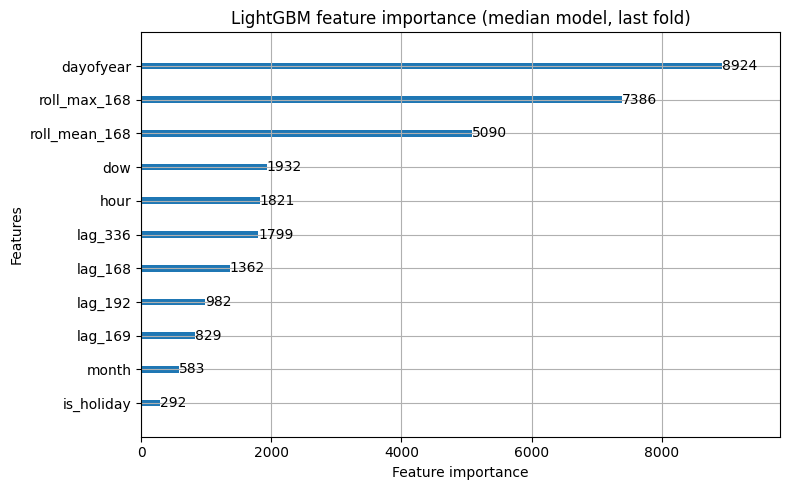

In [10]:
lgb.plot_importance(last_model, max_num_features=12, figsize=(8, 5),
                    title="LightGBM feature importance (median model, last fold)")
plt.tight_layout(); plt.show()

`dayofyear` dominates by a wide margin. The model leans heavily on "what time of year is it" to capture the yearly seasonal cycle, more than any single lag or rolling feature. The rolling window features rank 2nd and 3rd, suggesting recent-week demand levels matter more to the model than any individual point-in-time lag. Individual lags (`lag_168`, `lag_192`, `lag_169`, `lag_336`) all rank lower than the rolling aggregates, which is a bit counterintuitive. `is_holiday` is the least important feature by far (292), likely because holidays are rare events relative to total training rows, so the model has little data to learn holiday-specific patterns from, despite holidays being a known source of demand anomalies. `hour` and `dow` rank only mid-table, which is surprising given how strong the daily/weekly cycles looked in the earlier EDA plots. This may suggest that the rolling/lag features are already implicitly encoding much of that cyclic information, making the explicit calendar flags partially redundant.

## 7. Backtest comparison

In [11]:
res = pd.DataFrame(results)
summary = (res.groupby("model")[["MAE", "MAPE", "coverage90"]]
              .agg(["mean", "std"]).round(2))
summary

MAE          MAPE       coverage90       
                          mean     std  mean   std       mean    std
model                                                               
LightGBM (quantile)    2553.15  977.61  8.57  3.30      70.44  27.21
Prophet                2732.62  675.09  9.22  2.04      93.45   7.97
SARIMA (daily→hourly)  2444.75  753.82  8.05  2.24      95.04   5.82

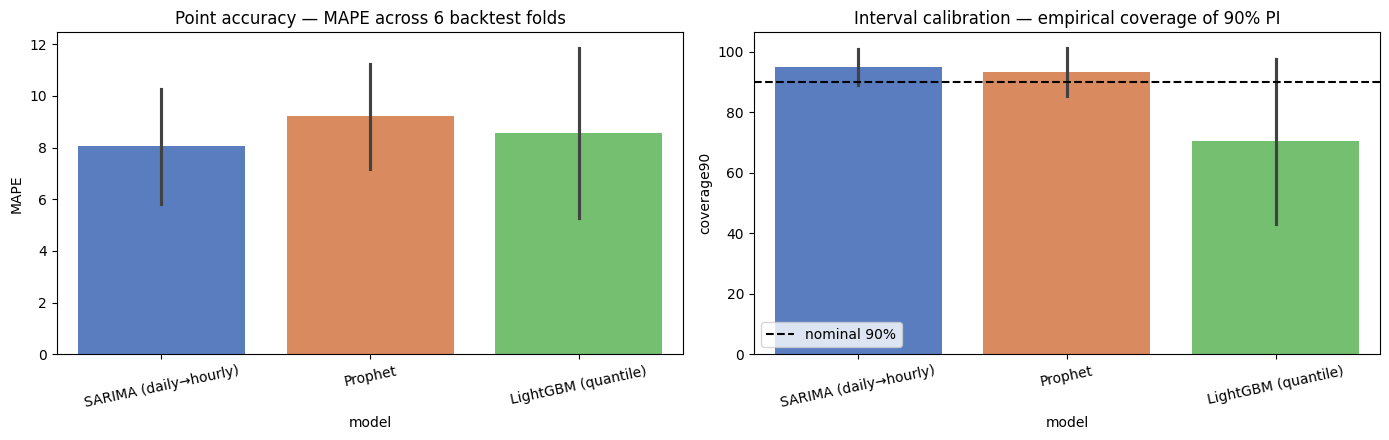

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.barplot(data=res, x="model", y="MAPE", errorbar="sd", ax=axes[0],
            hue="model", palette="muted", legend=False)
axes[0].set_title("Point accuracy — MAPE across 6 backtest folds")
axes[0].tick_params(axis="x", rotation=12)

sns.barplot(data=res, x="model", y="coverage90", errorbar="sd", ax=axes[1],
            hue="model", palette="muted", legend=False)
axes[1].axhline(90, ls="--", c="k", label="nominal 90%")
axes[1].set_title("Interval calibration — empirical coverage of 90% PI")
axes[1].tick_params(axis="x", rotation=12); axes[1].legend()

plt.tight_layout(); plt.show()

Point accuracy is close across all three models (MAPE 8.0–9.2% mean), no clear winner on this metric alone, and the overlapping error bars mean the differences likely aren't statistically meaningful with only 6 folds. SARIMA edges out on both mean MAPE (8.05%) and MAE (2444.75), despite being the simplistic model relative to Prophet and LightGBM. Calibration is where the models separate: SARIMA and Prophet both average >90% coverage (95.0% and 93.4%) whereas lightGBM lags badly at 70.4% mean coverage with huge variance. Its intervals are unreliable and swing from good to badly under-covered depending on the fold.
Bottom line: LightGBM is competitive (even best) on raw point accuracy in some folds, but its quantile intervals aren't trustworthy as-is. The variance in the coverage plot alone would disqualify it for any application where the uncertainty estimate matters, not just the point forecast. SARIMA's simplicity plus its calibration reliability make it the strongest all-around performer here, which is generally a pleasent takeaway. A subjective, vibes-based observation of the predictions on the test set would point to lightGBM as the best performer. It's coverage failure was highly concentrated in 2 periods.

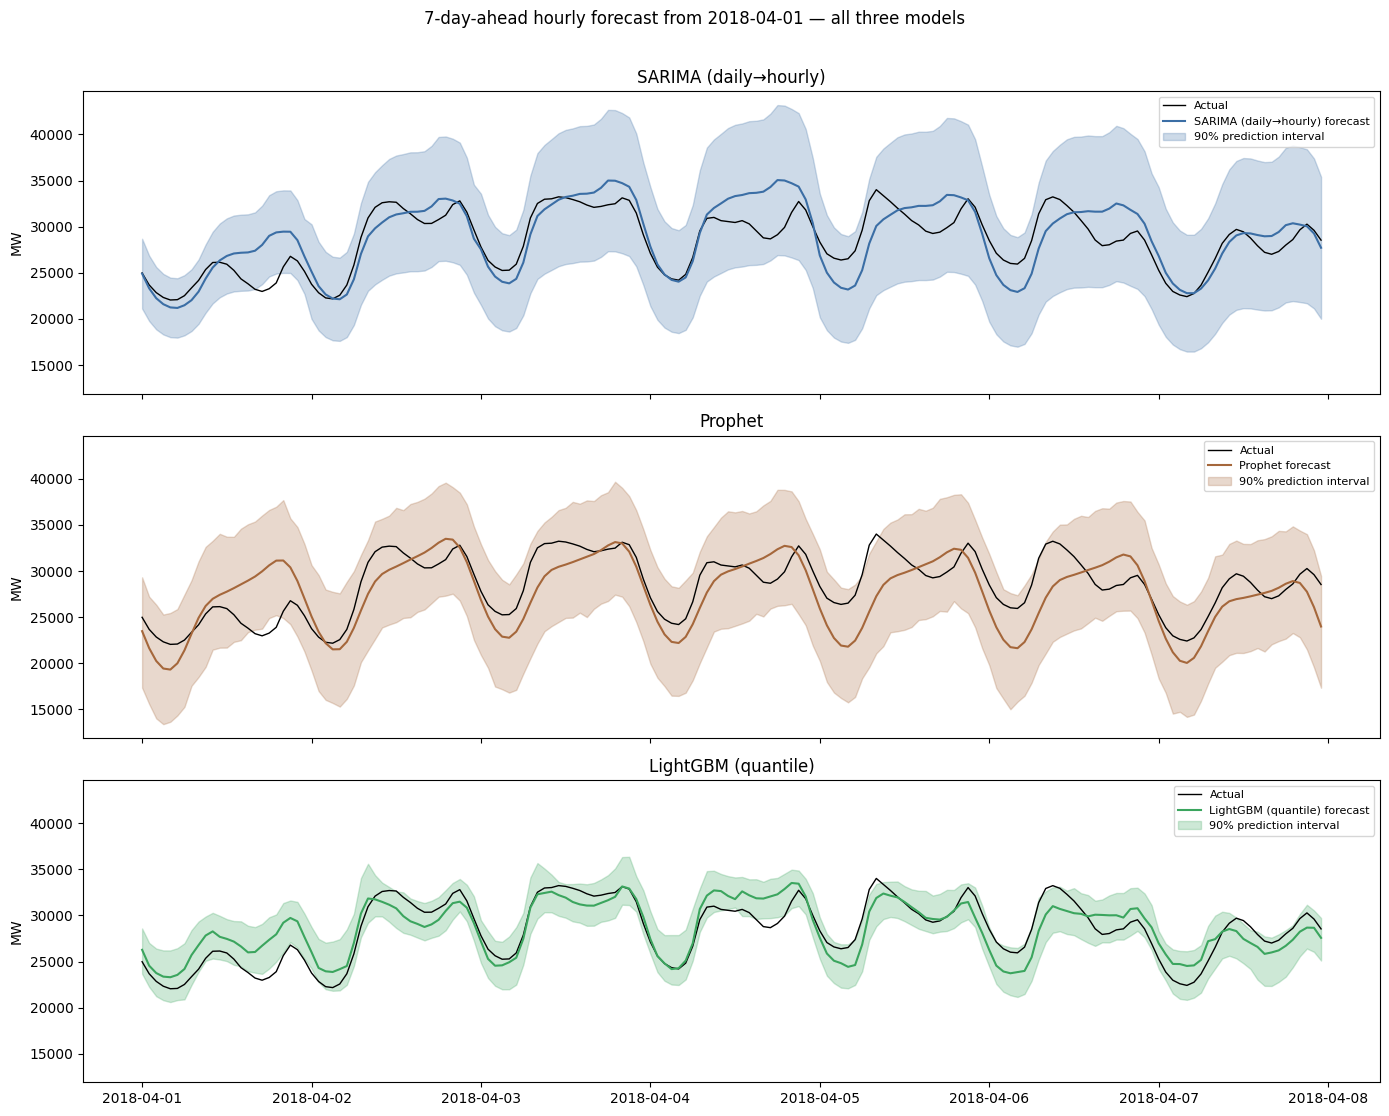

In [13]:
# Visualize the final fold: actuals vs. all three models' forecasts with 90% intervals
cutoff = cutoffs[-1]
train, test = backtest_frames(cutoff)

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True, sharey=True)

model_forecasts = [
    ("SARIMA (daily→hourly)", pred, lo, hi, "#3b6ea5"),
    ("Prophet", fc["yhat"].values, fc["yhat_lower"].values, fc["yhat_upper"].values, "#a5673b"),
    ("LightGBM (quantile)", preds[0.50], preds[0.05], preds[0.95], "#3ba55e"),
]

for ax, (name, median, low, high, color) in zip(axes, model_forecasts):
    ax.plot(test.index, test["y"], label="Actual", color="black", lw=1)
    ax.plot(test.index, median, label=f"{name} forecast", color=color)
    ax.fill_between(test.index, low, high, alpha=0.25, color=color, label="90% prediction interval")
    ax.set_title(name)
    ax.set_ylabel("MW")
    ax.legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("")
fig.suptitle(f"7-day-ahead hourly forecast from {cutoff.date()} — all three models", y=1.01)
plt.tight_layout()
plt.show()

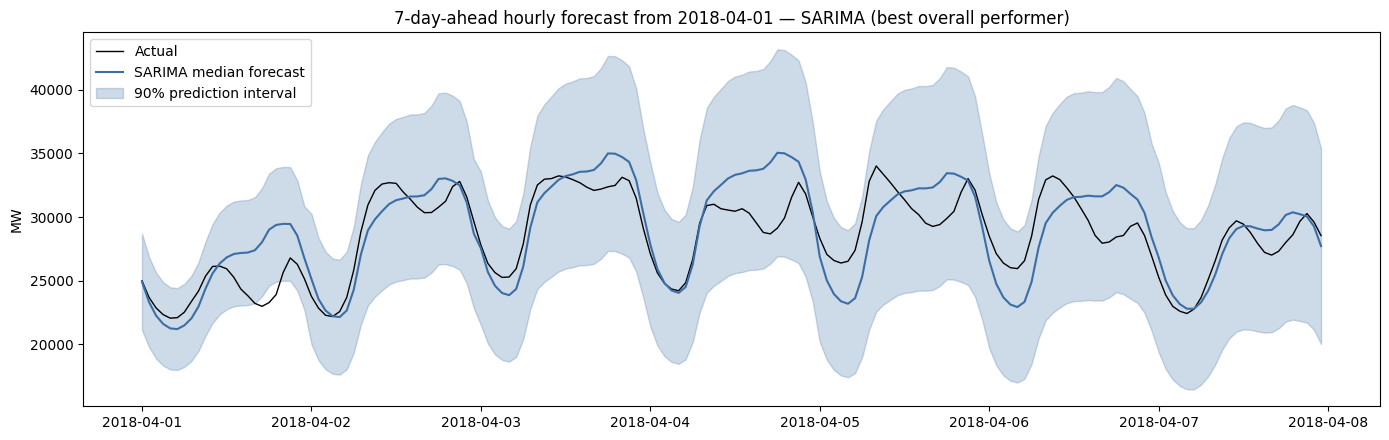

In [14]:
# Visualize the final fold: actuals vs. SARIMA forecast with 90% interval (best-calibrated model)
cutoff = cutoffs[-1]
train, test = backtest_frames(cutoff)

plt.figure(figsize=(14, 4.5))
plt.plot(test.index, test["y"], label="Actual", color="black", lw=1)
plt.plot(test.index, pred, label="SARIMA median forecast", color="#3b6ea5")
plt.fill_between(test.index, lo, hi, alpha=0.25,
                 color="#3b6ea5", label="90% prediction interval")
plt.title(f"7-day-ahead hourly forecast from {cutoff.date()} — SARIMA (best overall performer)")
plt.ylabel("MW"); plt.legend(); plt.tight_layout(); plt.show()

## Conclusions

- SARIMA, despite being the simplest and most "hacky" approach (daily model + intraday disaggregation), came out on top overall. Best mean MAPE (8.05%) and best calibration (95.0% mean coverage, low variance). The two-stage approximation clearly doesn't cost as much as expected at this horizon.
- LightGBM had the best point accuracy on individual folds (as low as 4.21% MAPE) and can express interactions like hour × weekday × season that additive models can't, but its quantile intervals are not reliable. A model whose uncertainty estimate can silently collapse like that isn't deployable as-is, even when its point forecasts look promising.
- Prophet sat in the middle, with generally strong accuracy and calibaration most of the time (93.4% mean coverage), with one notably bad fold (79% coverage, its worst MAPE too), for near-zero feature engineering effort.
- **Practical takeaway:** if this were a real deployment decision, SARIMA's reliability would beat LightGBM's occasional strength unless we fixed the quantile intervals.

### Limitations & next steps
- No weather features. Temperature is the single biggest demand driver, and joining temperature data would likely cut errors substantially and could specifically help LightGBM's worst folds, which may coincide with unusual weather.
- LightGBM's quantile intervals need recalibration.
- Only one region (PJME), we could run the same pipeline on all PJM regional files in the dataset for a robustness check, and would clarify whether SARIMA's win here is region-specific or general.